In [17]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from pathlib import Path

from pmt_fit_helpers import stage1_loss, simulate_gain, get_param, SCRATCH_DIR

# R11410-specific schematic/model files (12 dynodes, vs. R12699's 10)
BASE_ASC = Path("R11410 model - power law - S2 - vacuum curents calculated separately.asc")
BASE_INC = Path("pmt_model_R11410_v1.inc")

# Digitized gain-vs-HV dataset (arXiv:1202.2628), the Stage 1 fit target for R11410
_gain_data = np.genfromtxt("../Data/R11410 gain curve.csv", delimiter=',', skip_header=1)
target_voltage = _gain_data[:, 0]
target_gain = _gain_data[:, 1]

N_PE_LINEAR = 10  # low enough to keep every dynode far below its space-charge knee (see margin check below)

In [18]:
import json
from pathlib import Path

# Set to False to force re-running the optimizer even if a cached fit result exists.
USE_CACHED_FITS = True
STAGE1_CACHE = Path("stage1_fit_result.json")

### PMT per-dynode gain: `gain_0`, `k_gen`

Each dynode stage amplifies the incoming current by a gain $g_i$ that depends on the
voltage across that dynode gap, $\Delta V_i$:

$$I_i = g_i \, I_{i-1}$$

$g_i$ is a power law in $\Delta V_i$, with a low-voltage cutoff term:

$$g_i = k_{\rm gen}(\Delta V_i)\,\Delta V_i^{\,a}, \qquad
k_{\rm gen}(V) = \frac{k}{\sqrt{1 + V_0/V}}$$

In `pmt_model_R11410_v1.inc` this is `k_gen(V)` / `gain_0(V)`, with `V` floored at `Vmin=1mV`
via `vclamp(V) = max(V, Vmin)` purely to avoid a divide-by-zero at $V=0$ (real dynode
gaps never actually reach 0V). `k`, `a` are free parameters fit in Stage 1 below;
`V_0` is currently fixed at 0.

### Collection efficiency: `eta`

Not every electron emitted by one dynode is actually collected by the next --
`eta(V, Vknee)` models this as a sigmoid in the gap voltage $V$:

$$\eta(V, V_{\rm knee}) = \frac{1}{1 + \exp\left(\dfrac{V_{\rm knee} - \max(V,0)}{V_{\rm slope}}\right)}$$

$\eta \to 1$ once $V \gg V_{\rm knee}$ (full collection) and $\eta \to 0$ for
$V \ll V_{\rm knee}$. Unlike R12699's finalized model (which found sweeping the anode's
knee independently had no effect and merged to one shared `Vknee`), R11410's
`pmt_model_R11410_v1.inc` keeps `VkneeAnode` and `VkneeOther` as separate parameters --
both currently seeded at R12699's fitted value (35V) as a starting point, pending
R11410-specific Stage 2 data to actually fit them. `Vslope` is shared across all gaps.

### Space-charge saturation: `space_charge`

At high current, the electron cloud between two dynodes distorts the local field
enough to reduce gain -- this is the actual physical saturation effect this whole
project is trying to characterize. `space_charge(Iin, Vgap, Isc)`:

$$S(I_{\rm in}, V_{\rm gap}, I_{sc}) = \frac{1}{1 + \left(\dfrac{|I_{\rm in}\cdot
{\rm gain\_0}(V_{\rm gap})|}{I_{sc}}\right)^{m}}$$

Note the current term is $I_{\rm in}\cdot{\rm gain\_0}(V_{\rm gap})$ -- the *output*
current this stage is about to emit (input current already amplified by this
stage's own gain), not the raw input current. That's why `gain_0` appears inside
`space_charge`'s own definition.

R11410 has 12 dynodes (vs. R12699's 10), so the last five carry a finite $I_{sc}$
(`Isc8, Isc9, Isc10, Isc11, Isc12` -- all free Stage 2 parameters, along with the shared
exponent `m`); every other dynode uses `IscDefault=1e9`, which makes $S\approx 1$
(no saturation) since current density is far lower there.

### Combined per-dynode gain: `g_effective`

The behavioral current sources in the schematic multiply the three effects above
together into a single effective gain per stage:

$$g_{\rm eff}(V_{\rm gap}, V_{\rm collect}, I_{\rm in}, V_{\rm knee}, I_{sc}) =
{\rm gain\_0}(V_{\rm gap}) \cdot \eta(V_{\rm collect}, V_{\rm knee}) \cdot
S(I_{\rm in}, V_{\rm gap}, I_{sc})$$

This is `g_effective(...)` in `pmt_model_R11410_v1.inc` -- everything above (`k, a, V_0,
VkneeAnode, VkneeOther, Vslope, Isc8-12, m`) is a parameter of this one
formula, evaluated once per dynode stage in the SPICE netlist.

### Sanity check: staying in the linear regime for Stage 1

Stage 1 only fits the basic gain law (`k, a`) and assumes saturation effects are
negligible at the operating point used. This cell confirms that assumption holds:
at `N_pe=10` and the highest-HV point in the dataset (worst case for dynode
current), the peak current at every space-charge-limited stage should sit orders
of magnitude below its `Isc` -- i.e. deep in the regime where
`space_charge(...)` $\approx 1$ and `gain_0`/`k_gen` alone describe the gain.

In [19]:
# Linear-regime sanity check: at N_PE_LINEAR and the highest-HV point in the dataset
# (worst case for dynode current), confirm every space-charge-limited stage's peak
# current is orders of magnitude below its Isc, so the "linear regime" assumption
# behind the N_PE_LINEAR choice actually holds given pmt_model_R11410_v1.inc's own numbers.
from pmt_fit_helpers import _execute, peak_abs_trace

_inc_text = BASE_INC.read_text()
_worst_v1 = float(target_voltage.max())
_raw_path = _execute(
    v1=_worst_v1, n_pe=N_PE_LINEAR,
    extra_save_nodes=["V(IV8)", "V(IV9)", "V(IV10)", "V(IV11)", "V(IV12)"],
    run_name="margin_check",
    asc_path=BASE_ASC, inc_path=BASE_INC,
)
for trace, isc_name in [("V(IV8)", "Isc8"), ("V(IV9)", "Isc9"), ("V(IV10)", "Isc10"),
                         ("V(IV11)", "Isc11"), ("V(IV12)", "Isc12")]:
    peak = peak_abs_trace(_raw_path, trace, window=(10e-6, 20e-6))
    isc_value = get_param(_inc_text, isc_name)
    print(f"{trace}: peak={peak:.3e} A vs {isc_name}={isc_value:.3e} A -> margin {isc_value/peak:.2e}x")

V(IV8): peak=2.113e-08 A vs Isc8=8.405e-01 A -> margin 3.98e+07x
V(IV9): peak=1.086e-07 A vs Isc9=2.027e-01 A -> margin 1.87e+06x
V(IV10): peak=5.585e-07 A vs Isc10=1.541e-01 A -> margin 2.76e+05x
V(IV11): peak=2.871e-06 A vs Isc11=1.000e-01 A -> margin 3.48e+04x
V(IV12): peak=1.476e-05 A vs Isc12=1.000e-01 A -> margin 6.77e+03x


In [8]:
# Quick look at the fit's starting point (pmt_model_R11410_v1.inc's current k,a) before optimizing
_k0 = get_param(_inc_text, "k")
_a0 = get_param(_inc_text, "a")
print(f"Initial guess from pmt_model_R11410_v1.inc: k={_k0:.4f}, a={_a0:.4f}\n")
print(f"{'V1 (V)':>8}  {'sim gain':>12}  {'target gain':>12}")
for v1, g_target in zip(target_voltage, target_gain):
    g_sim = simulate_gain(v1, N_PE_LINEAR, inc_params={"k": _k0, "a": _a0}, asc_path=BASE_ASC, inc_path=BASE_INC)
    print(f"{v1:8.0f}  {g_sim:12.3e}  {g_target:12.3e}")

Initial guess from pmt_model_R11410_v1.inc: k=0.0907, a=0.8114

  V1 (V)      sim gain   target gain


     996     7.417e+04     6.769e+04
    1096     1.611e+05     1.571e+05
    1196     3.277e+05     3.443e+05
    1297     6.325e+05     6.830e+05
    1399     1.171e+06     1.210e+06


KeyboardInterrupt: 

### Stage 1 fit: `k`, `a` vs. gain-vs-HV data

Free parameters: `k, a` (`V_0` held fixed at 0). Target: the 7-point gain-vs-HV
dataset above, at a fixed low `N_pe=10` (linear regime, confirmed above). For each
candidate `(k,a)`, `stage1_loss` runs one SPICE `.tran` per HV point and computes

$$\mathcal{L} = \sum_i \left(\log_{10} g_{\rm target}(V_i) - \log_{10}
g_{\rm sim}(V_i)\right)^2$$

minimized with `scipy.optimize.minimize` (Nelder-Mead).

In [9]:
bounds = [(0.05, 0.2), (0.6, 1.0)]  # same bounds as R12699's approved plan; revisit if the fit pins against either edge
initial_guess = [_k0, _a0]

if USE_CACHED_FITS and STAGE1_CACHE.exists():
    _cached1 = json.loads(STAGE1_CACHE.read_text())
    best_k, best_a = _cached1["k"], _cached1["a"]
    print(f"Loaded cached Stage 1 fit from {STAGE1_CACHE}: k={best_k:.5f}, a={best_a:.5f} "
          f"(loss={_cached1['loss']:.3e})")
else:
    print("Starting Stage 1 optimization (k, a)...")
    result = minimize(
        stage1_loss, initial_guess,
        args=(target_voltage, target_gain, N_PE_LINEAR, SCRATCH_DIR, BASE_ASC, BASE_INC),
        bounds=bounds, method='Nelder-Mead',
        options={'xatol': 1e-4, 'fatol': 1e-6},
    )
    best_k, best_a = result.x
    print(f"\nStage 1 fit complete: k={best_k:.5f}, a={best_a:.5f}  "
          f"(loss={result.fun:.3e}, {result.nit} iters, {result.nfev} evals)")
    STAGE1_CACHE.write_text(json.dumps(
        {"k": best_k, "a": best_a, "loss": result.fun, "nit": result.nit, "nfev": result.nfev},
        indent=2))
    print(f"Saved fit to {STAGE1_CACHE}")

Loaded cached Stage 1 fit from stage1_fit_result.json: k=0.09070, a=0.81138 (loss=4.346e-03)


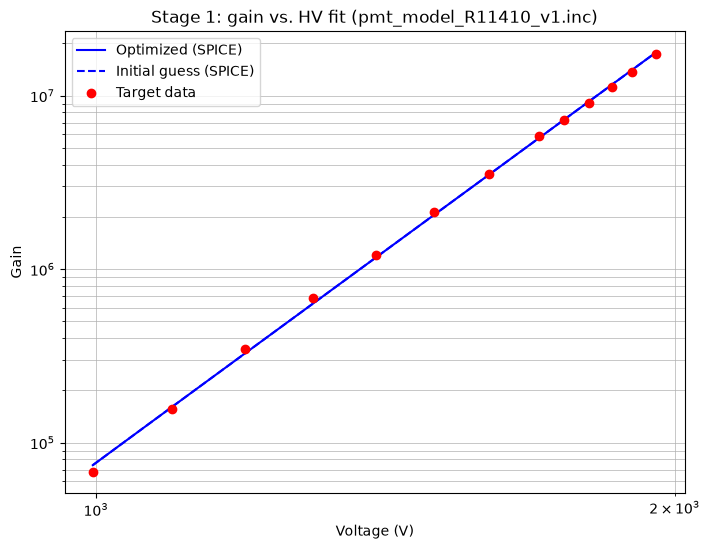

In [10]:
voltage_curve = np.linspace(target_voltage.min(), target_voltage.max(), 15)
initial_gain_curve = np.array([simulate_gain(v, N_PE_LINEAR, inc_params={"k": _k0, "a": _a0}, asc_path=BASE_ASC, inc_path=BASE_INC) for v in voltage_curve])
final_gain_curve = np.array([simulate_gain(v, N_PE_LINEAR, inc_params={"k": best_k, "a": best_a}, asc_path=BASE_ASC, inc_path=BASE_INC) for v in voltage_curve])

plt.figure(figsize=(8, 6))
plt.plot(voltage_curve, final_gain_curve, label='Optimized (SPICE)', color='blue')
plt.plot(voltage_curve, initial_gain_curve, label='Initial guess (SPICE)', color='blue', linestyle='--')
plt.scatter(target_voltage, target_gain, label='Target data', color='red', zorder=5)
plt.xlabel('Voltage (V)')
plt.ylabel('Gain')
plt.title('Stage 1: gain vs. HV fit (pmt_model_R11410_v1.inc)')
plt.legend()
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.xscale('log')
plt.yscale('log')
plt.show()

### Writing the fit back to `pmt_model_R11410_v1.inc`

Only `k` and `a` are updated here -- Stage 2 (`Isc8-12`, `VkneeAnode`, `VkneeOther`,
`Vslope`, `m`) stays at its R12699-copied placeholder values until a real R11410
saturation/linearity dataset is available to fit against (see the project root's
`model_fitting.ipynb` for the full R12699 Stage 2 pipeline this will eventually mirror).

In [11]:
# Write the fitted k, a into the tracked pmt_model_R11410_v1.inc. This is the only
# point in the notebook that mutates the tracked file itself -- everything above only
# ever touched scratch copies during optimization.
from pmt_fit_helpers import set_param

_inc_final = BASE_INC.read_text()
for _name, _value in {"k": best_k, "a": best_a}.items():
    _inc_final = set_param(_inc_final, _name, _value)
BASE_INC.write_text(_inc_final)

print(f"Wrote fitted k, a into {BASE_INC}:")
print(f"  k = {best_k:.6g}")
print(f"  a = {best_a:.6g}")

Wrote fitted k, a into pmt_model_R11410_v1.inc:
  k = 0.0906977
  a = 0.81138


## Diagnostic plots: dynode gap voltages & anode current vs. pulse size

Fixed HV (`DIAG_V1=1550V`), sweeping `N_pe` across 11 log-spaced points from 1e3 to 3e6.
For each `(config, N_pe)` point, a two-panel figure shows dynode-to-dynode gap voltages
(left) and the anode current through the 50-ohm sense resistor, `I(R1)` (right), side by
side, both vs. time. Four configurations are compared, each building on the last:

1. Gain-only model -- collection efficiency and space charge both effectively disabled
2. Collection efficiency on (`VkneeAnode=VkneeOther=10V`, `Vslope=1V`), space charge still off
3. Collection efficiency on (`VkneeAnode=VkneeOther=30V`, `Vslope=10V`), space charge still off
4. Same as (3), plus space charge on (`Isc=0.05A`, `m=2` on the last five dynodes)

All 44 frames (4 configs x 11 `N_pe` points) are rendered once, compressed with Pillow,
and shown through a single two-slider HTML/JS viewer below instead of as 44 stacked
matplotlib figures -- drag the sliders to flip between configs/`N_pe` instead of
scrolling through a wall of plots.

In [20]:
from PyLTSpice import RawRead
from pmt_fit_helpers import SimTimeoutError

DIAG_V1 = 1550.0
DIAG_N_PE = np.logspace(np.log10(1e3), np.log10(3e7), 31)
DYNODES = [f"DY{i}" for i in range(1, 13)]

def run_diagnostic(n_pe, inc_params, run_name="diag"):
    """Run one .tran at DIAG_V1/n_pe with the given inc_param overrides, saving every
    dynode node. I(R1) (the anode sense-resistor current) is already in the schematic's
    default `.save` directive, so no extra_save_nodes needed for it. Returns
    (time, {dynode: voltage}, anode_current)."""
    raw_path = _execute(
        v1=DIAG_V1, n_pe=n_pe, inc_params=inc_params,
        extra_save_nodes=[f"V({d})" for d in DYNODES],
        run_name=run_name, asc_path=BASE_ASC, inc_path=BASE_INC,
    )
    raw = RawRead(str(raw_path))
    t = raw.get_trace("time").get_wave()
    dy = {d: raw.get_trace(f"V({d})").get_wave() for d in DYNODES}
    anode_current = raw.get_trace("I(R1)").get_wave()
    return t, dy, anode_current

In [21]:
def make_diagnostic_figure(t, dy, anode_current, n_pe, title):
    """Side-by-side figure for one (config, N_pe) point: dynode gap voltages (left) and
    anode current through the 50-ohm sense resistor I(R1) (right), both vs. time."""
    t_us = t * 1e6
    fig, (ax_gap, ax_curr) = plt.subplots(1, 2, figsize=(13, 5))

    for i in range(1, len(DYNODES)):
        gap = dy[DYNODES[i]] - dy[DYNODES[i - 1]]
        ax_gap.plot(t_us, gap, label=f"{DYNODES[i]}-{DYNODES[i-1]}")
    ax_gap.set_xlabel("Time (us)")
    ax_gap.set_ylabel("Dynode gap voltage (V)")
    ax_gap.legend(fontsize=7, ncol=2, loc="upper right")
    ax_gap.grid(True)

    ax_curr.plot(t_us, anode_current * 1e3, color="k")
    ax_curr.set_xlabel("Time (us)")
    ax_curr.set_ylabel("Anode current I(R1) (mA)")
    ax_curr.grid(True)

    fig.suptitle(title + f"\nN_pe={n_pe:.3e}, V1={DIAG_V1:.0f}V")
    fig.tight_layout()
    return fig

In [22]:
import base64
import json as _json
import uuid
from io import BytesIO

from PIL import Image, ImageDraw

def fig_to_data_uri(fig, max_width=650):
    """Render a matplotlib figure to PNG, downsize it with Pillow, and return a base64
    data URI. Closes the figure so building dozens of frames for the slider gallery below
    doesn't leave that many live matplotlib figures around -- the notebook only ever
    stores the (much smaller) compressed frames, not 44 full-res inline plots."""
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=100)
    plt.close(fig)
    buf.seek(0)
    img = Image.open(buf)
    if img.width > max_width:
        scale = max_width / img.width
        img = img.resize((max_width, round(img.height * scale)), Image.LANCZOS)
    out = BytesIO()
    img.save(out, format="PNG", optimize=True)
    return "data:image/png;base64," + base64.b64encode(out.getvalue()).decode("ascii")


def placeholder_frame(text, size=(650, 250)):
    """Pillow-drawn placeholder for (config, N_pe) points where LTspice failed to
    converge, so a bad grid cell shows a labeled blank instead of breaking the slider."""
    img = Image.new("RGB", size, color=(240, 240, 240))
    draw = ImageDraw.Draw(img)
    draw.multiline_text((10, size[1] // 2 - 20), text, fill=(150, 0, 0))
    out = BytesIO()
    img.save(out, format="PNG")
    return "data:image/png;base64," + base64.b64encode(out.getvalue()).decode("ascii")


def slider_gallery(frames_2d, row_labels, col_labels, row_title="Config", col_title="N_pe"):
    """Two-slider HTML/JS image viewer for a [row][col] grid of data-URI frames -- avoids
    an ipywidgets dependency (not installed in this env), just a couple of <input
    type=range> elements and plain JS swapping an <img> src. Each call gets a random
    element-id prefix so multiple galleries in one notebook don't collide."""
    gid = uuid.uuid4().hex[:8]
    return f"""
<div id="gallery-{gid}" style="font-family: sans-serif;">
  <b><span id="rowlabel-{gid}"></span></b>
  <input id="rowslider-{gid}" type="range" min="0" max="{len(row_labels) - 1}" value="0"
         style="width:400px; display:block;">
  <div style="font-size:smaller; color:#555;">{row_title}</div>
  <b style="display:block; margin-top:8px;"><span id="collabel-{gid}"></span></b>
  <input id="colslider-{gid}" type="range" min="0" max="{len(col_labels) - 1}" value="0"
         style="width:400px; display:block;">
  <div style="font-size:smaller; color:#555;">{col_title}</div>
  <img id="img-{gid}" style="max-width:100%; margin-top:10px; border:1px solid #ccc;">
</div>
<script>
(function() {{
  const frames = {_json.dumps(frames_2d)};
  const rowLabels = {_json.dumps(row_labels)};
  const colLabels = {_json.dumps(col_labels)};
  const rowSlider = document.getElementById("rowslider-{gid}");
  const colSlider = document.getElementById("colslider-{gid}");
  const rowLabelEl = document.getElementById("rowlabel-{gid}");
  const colLabelEl = document.getElementById("collabel-{gid}");
  const img = document.getElementById("img-{gid}");
  function update() {{
    const i = parseInt(rowSlider.value), j = parseInt(colSlider.value);
    img.src = frames[i][j];
    rowLabelEl.textContent = rowLabels[i];
    colLabelEl.textContent = colLabels[j];
  }}
  rowSlider.addEventListener("input", update);
  colSlider.addEventListener("input", update);
  update();
}})();
</script>
"""

### Configurations swept: gain-only -> collection efficiency -> + space charge

Each config below builds on the last (see the four bullets in the intro above). Running
all of them here (rather than one config per cell) is what lets the slider gallery show
every `(config, N_pe)` combination through one widget.

Skipping '1. Gain-only model (collection efficiency + space charge disabled)' at N_pe=1.361e+06: LTspice failed to converge (LTspice run failed (rc=1).
stdout: 
stderr: )
Skipping '1. Gain-only model (collection efficiency + space charge disabled)' at N_pe=1.920e+06: LTspice failed to converge (LTspice run failed (rc=1).
stdout: 
stderr: )
Skipping '1. Gain-only model (collection efficiency + space charge disabled)' at N_pe=2.707e+06: LTspice failed to converge (LTspice run failed (rc=1).
stdout: 
stderr: )
Skipping '1. Gain-only model (collection efficiency + space charge disabled)' at N_pe=3.817e+06: LTspice failed to converge (LTspice run failed (rc=1).
stdout: 
stderr: )
Skipping '1. Gain-only model (collection efficiency + space charge disabled)' at N_pe=5.382e+06: LTspice failed to converge (LTspice run failed (rc=1).
stdout: 
stderr: )
Skipping '1. Gain-only model (collection efficiency + space charge disabled)' at N_pe=7.589e+06: LTspice failed to converge (LTspice run failed (


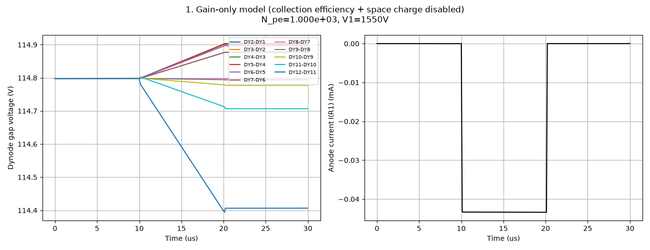
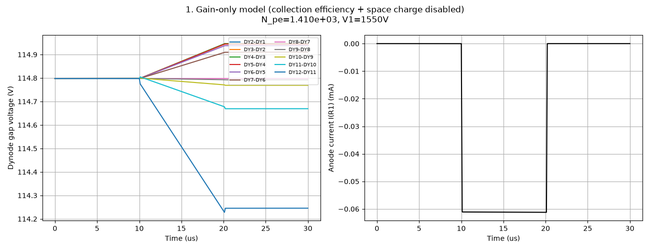
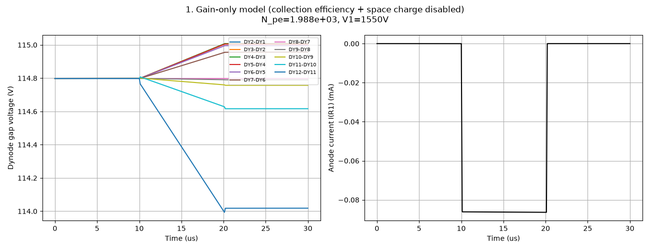
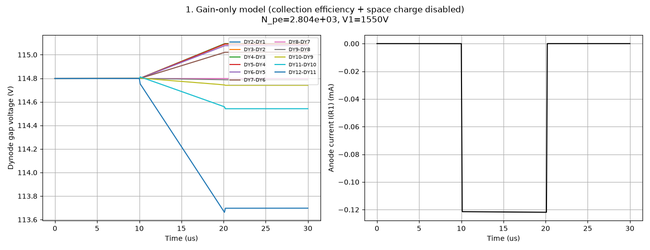
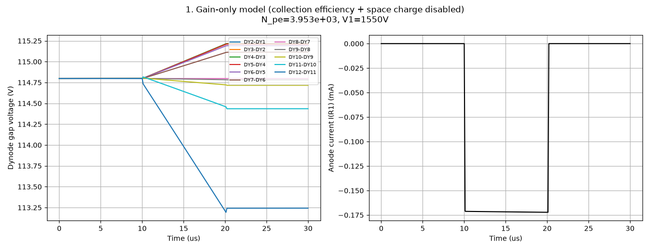
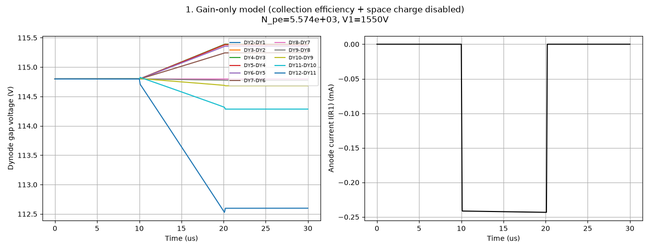
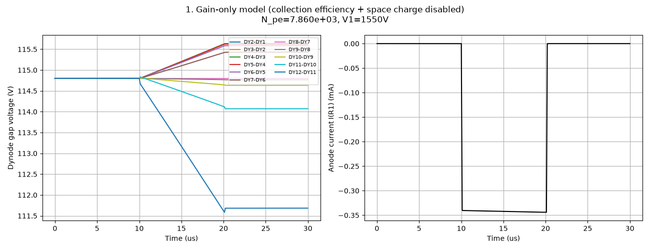
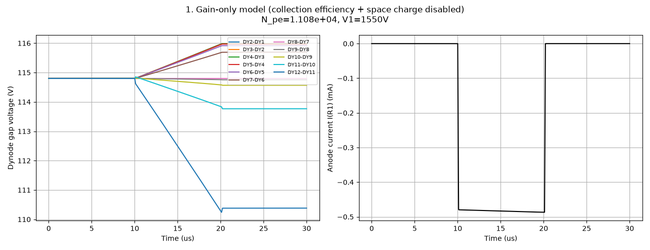
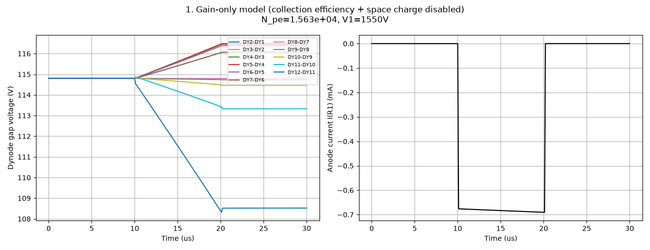
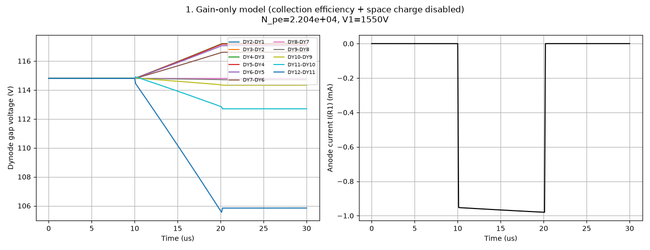
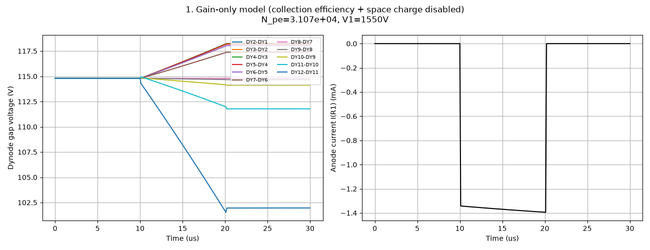
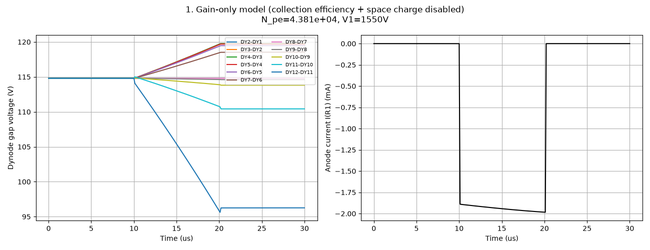
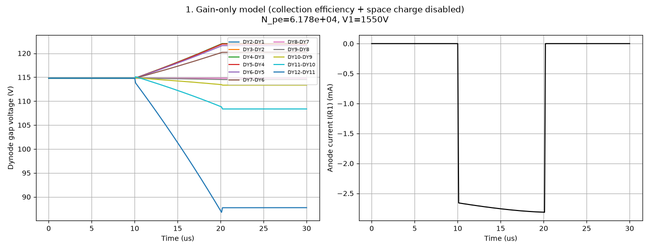
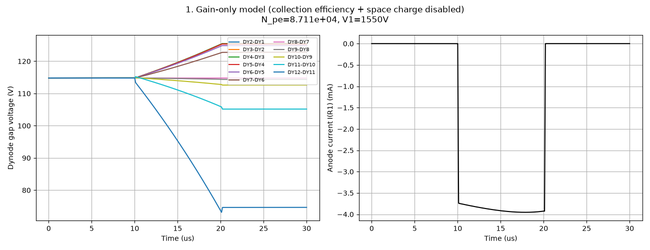
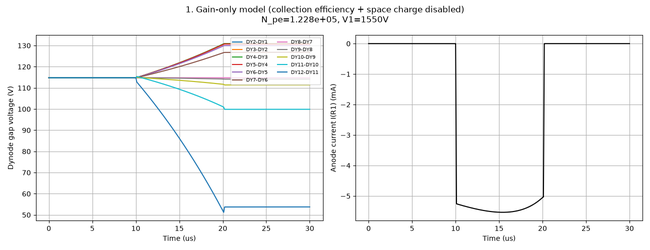
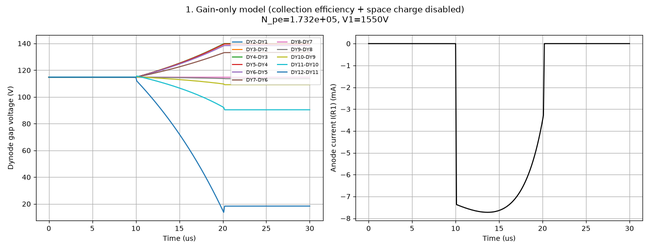
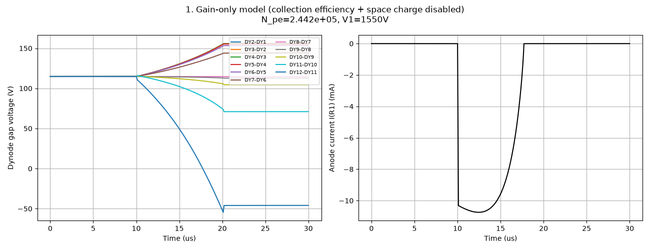
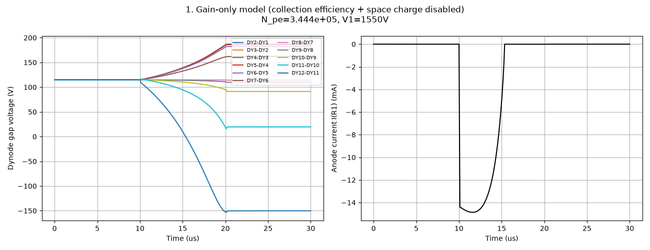
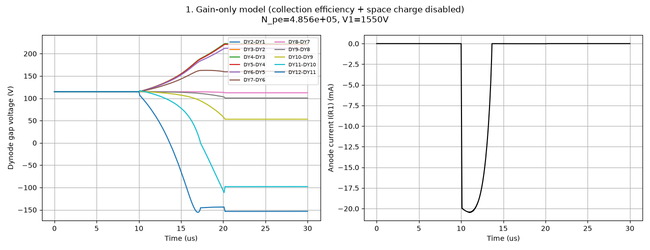
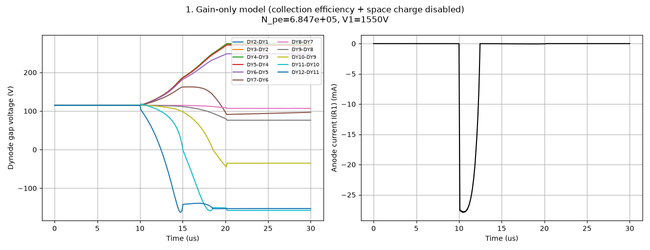
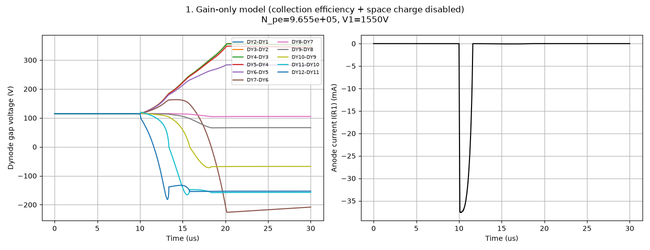
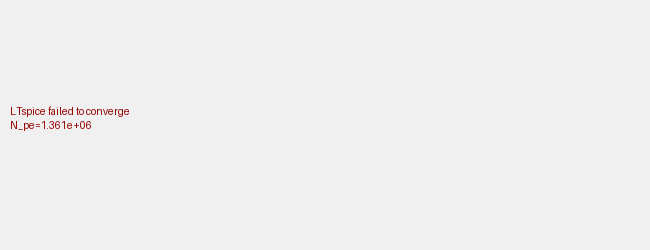
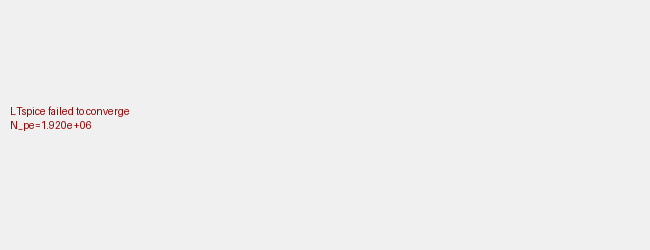
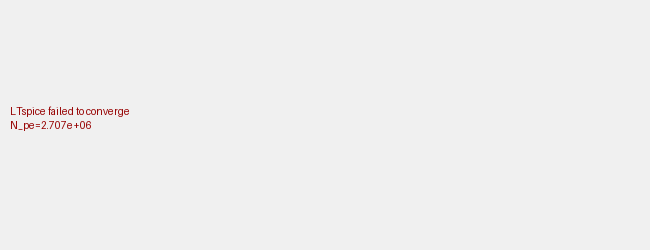
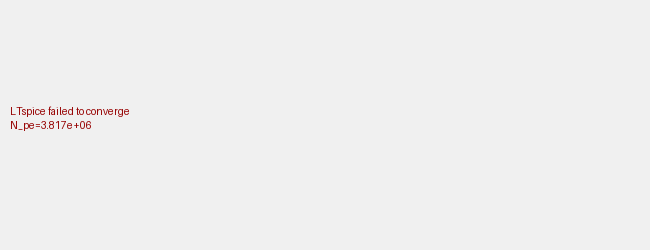
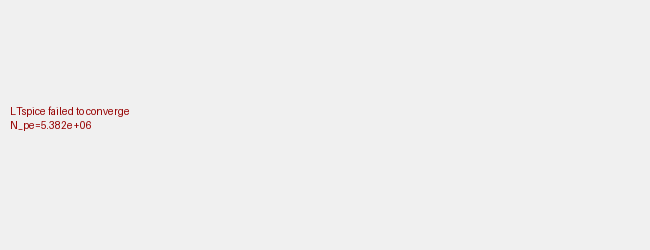
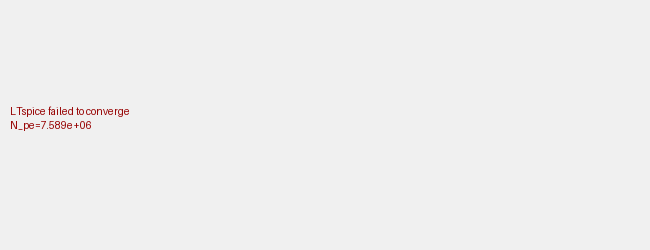
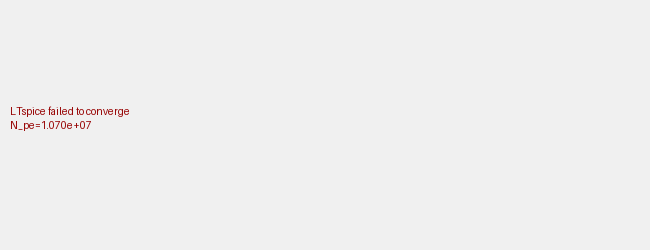
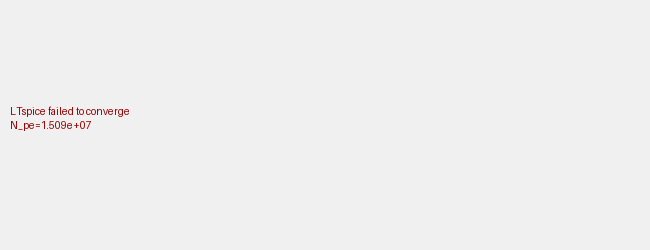
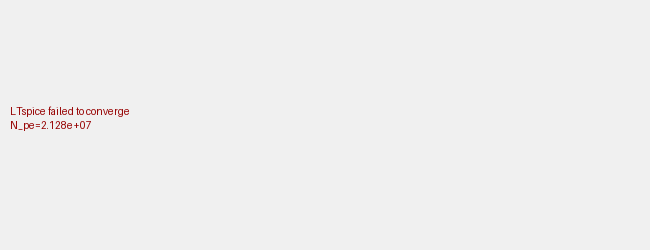
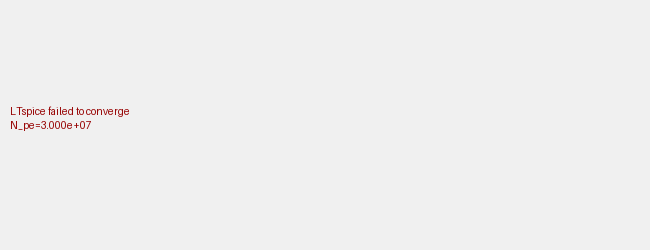
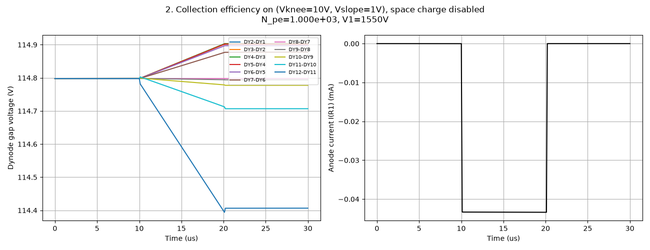
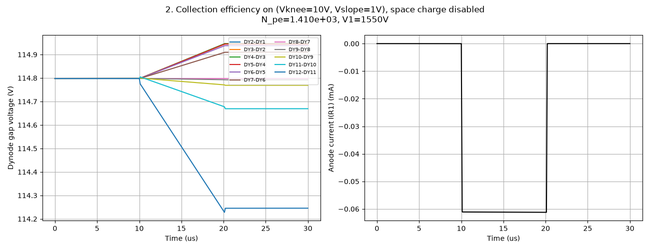
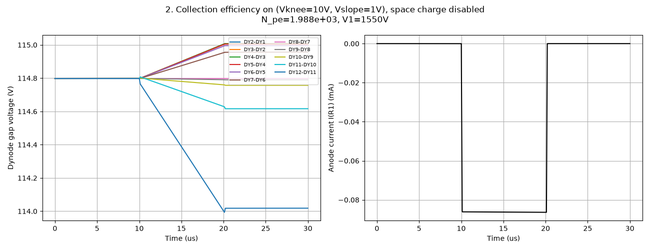
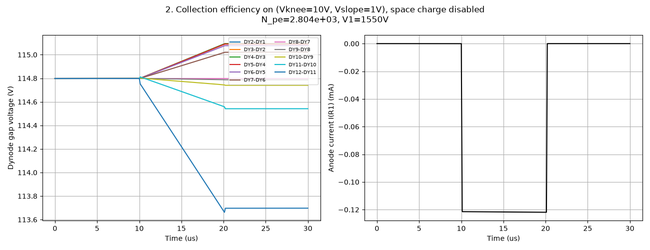
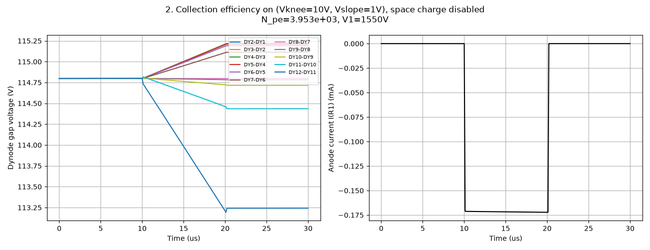
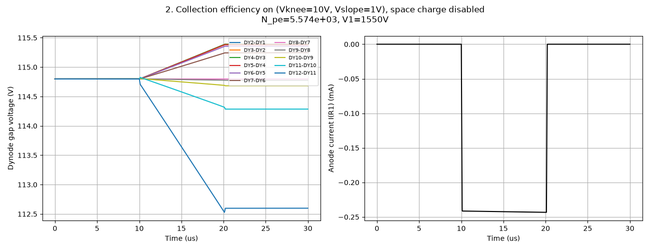
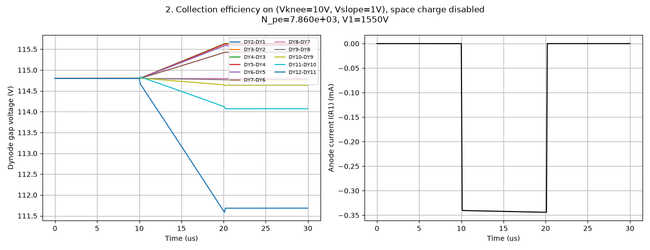
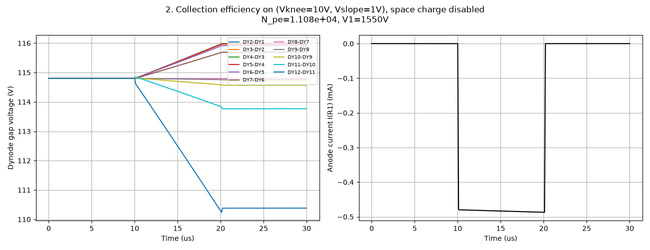
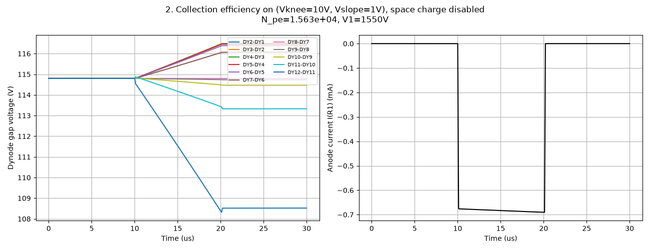
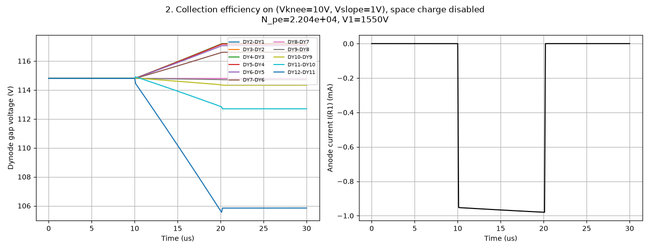
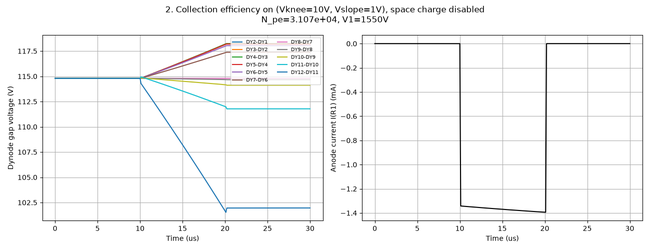
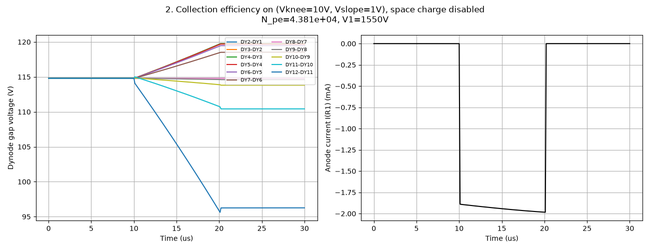
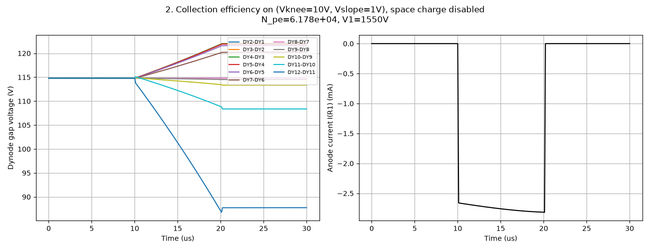
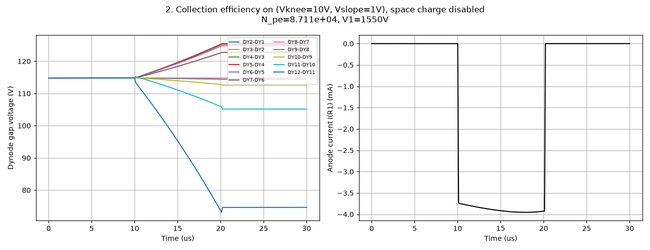
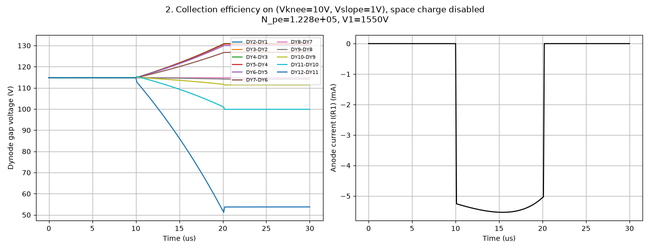
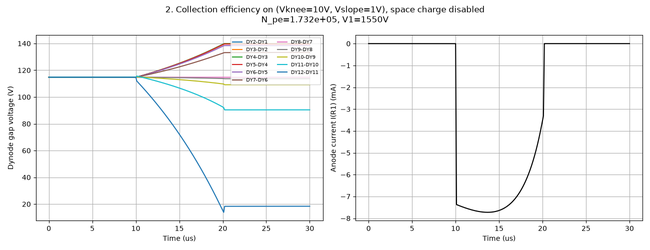
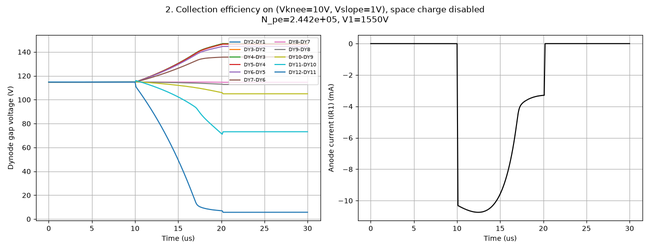
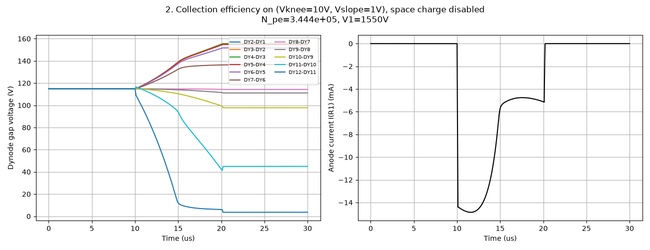
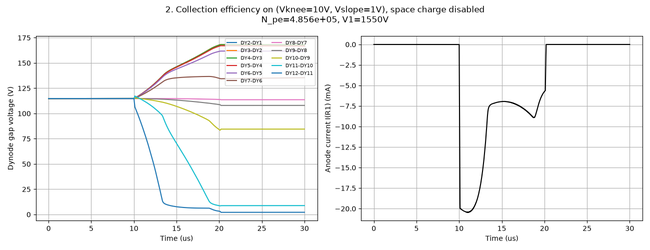
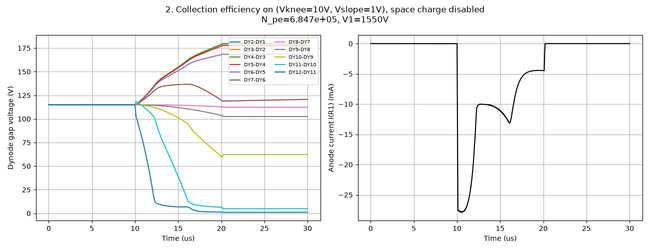
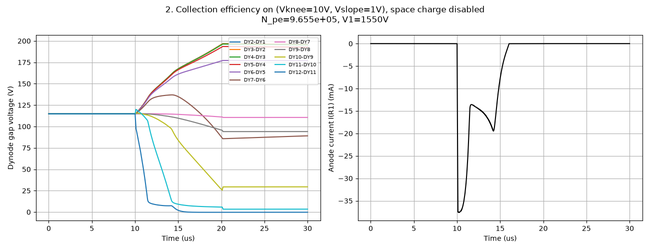
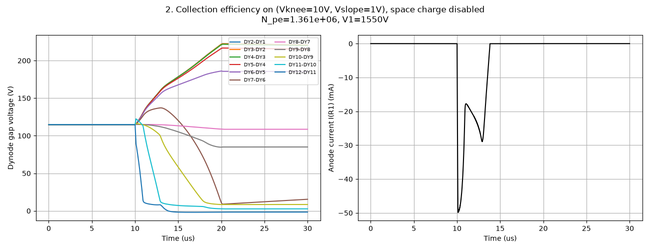
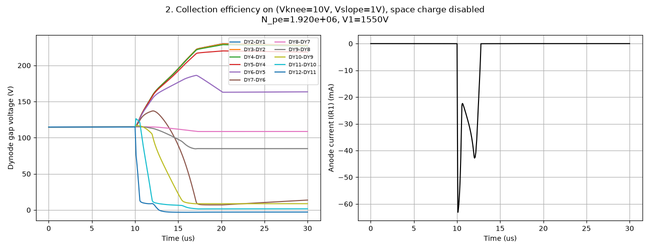
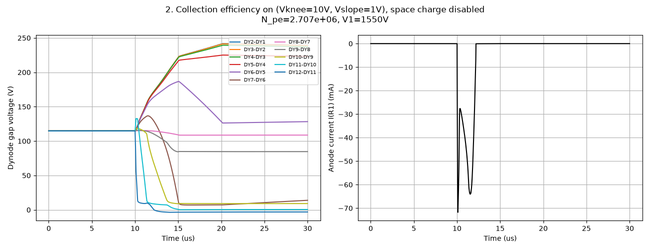
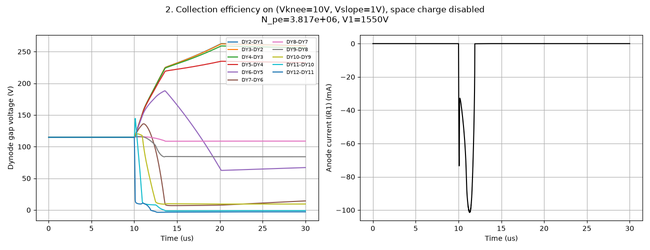
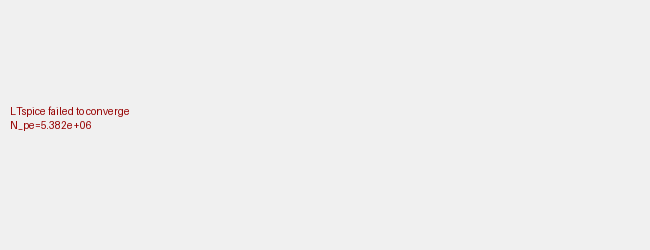
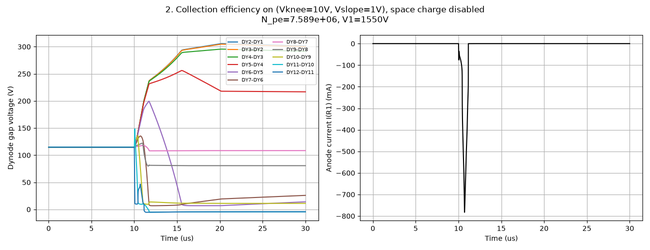
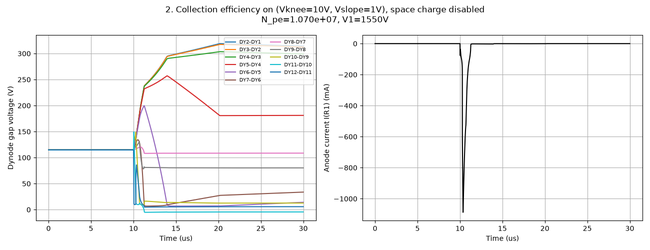
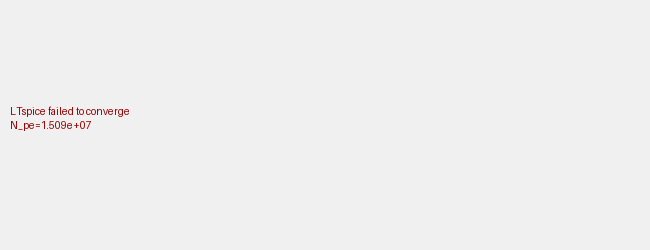
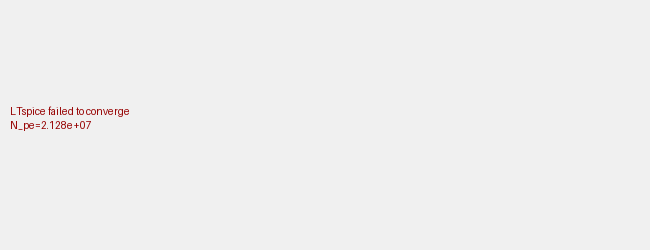
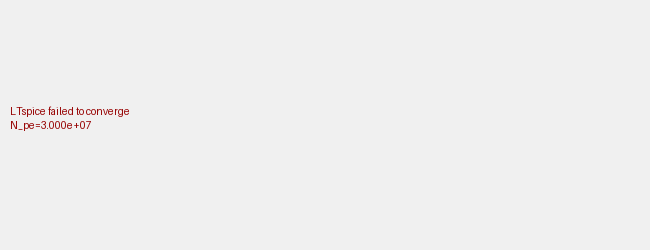
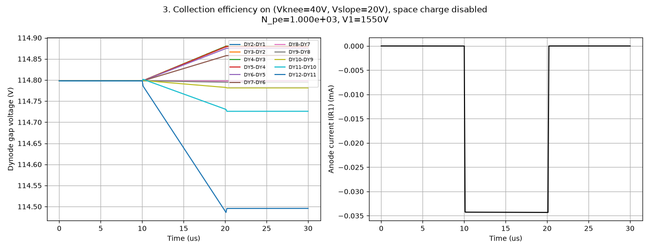
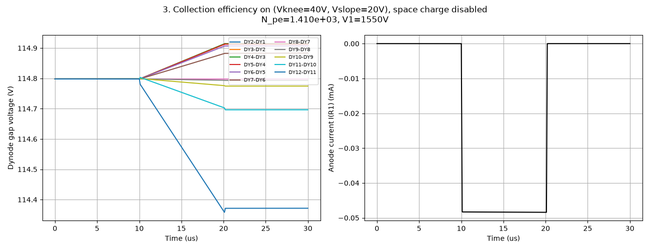
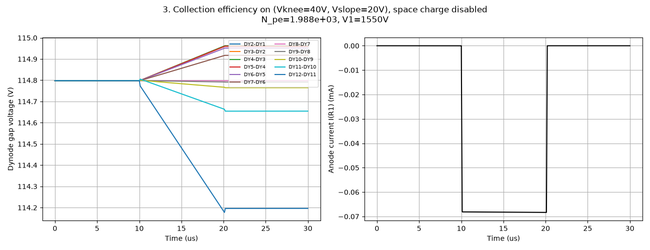
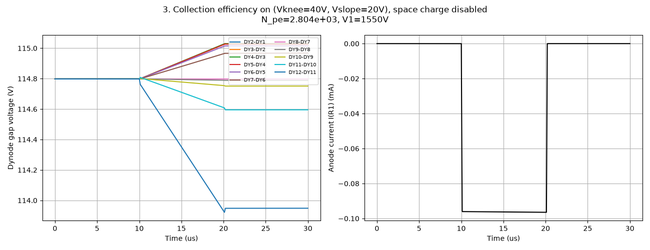
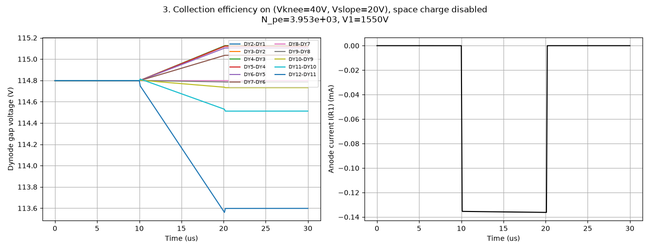
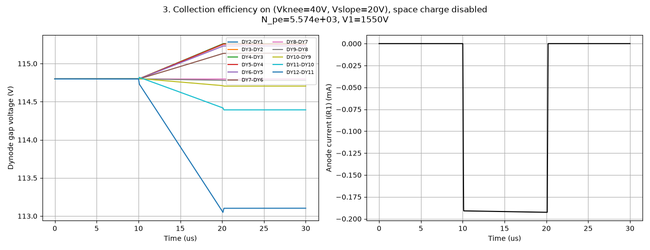
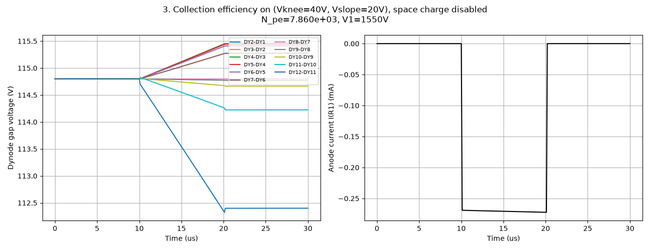
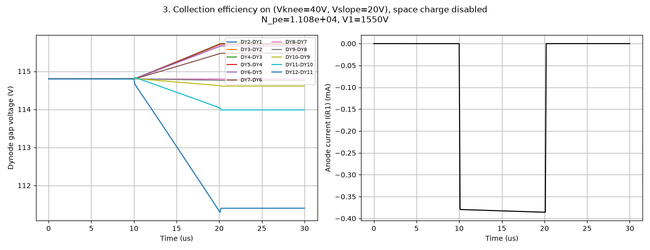
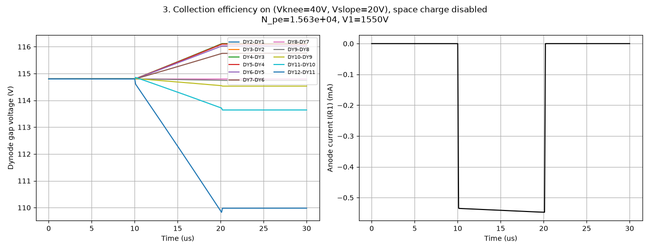
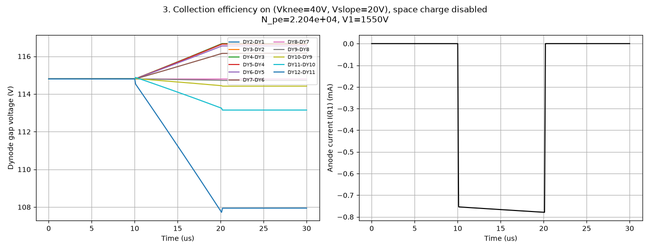
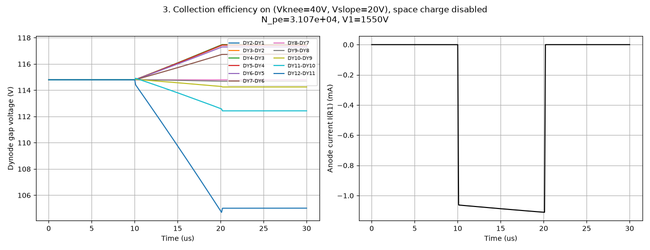
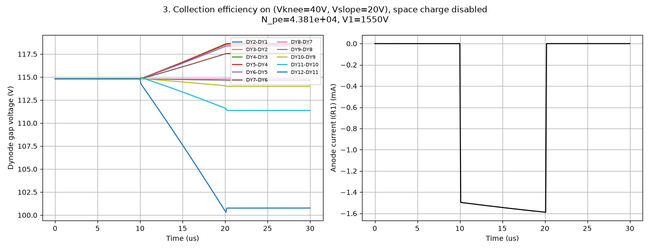
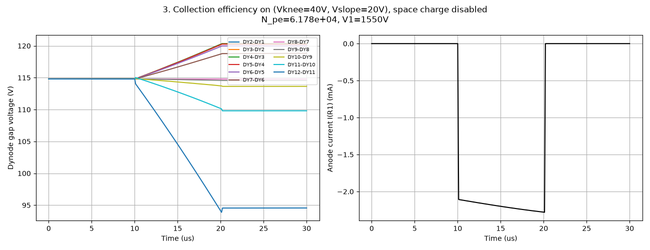
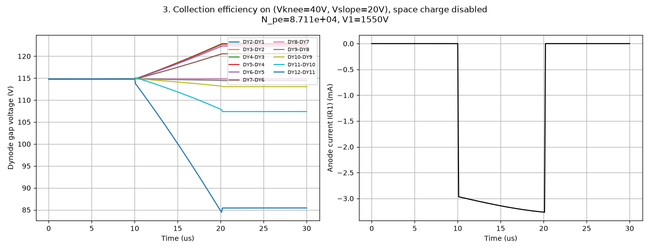
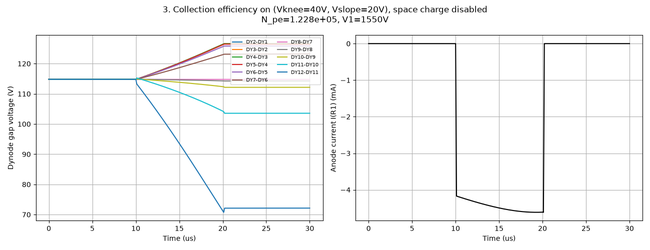
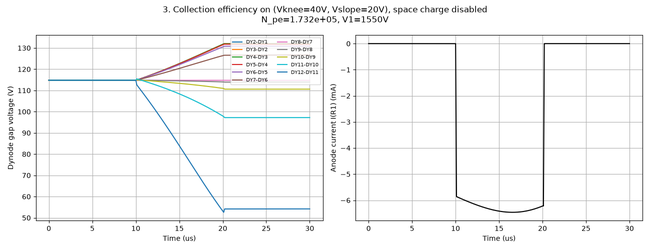
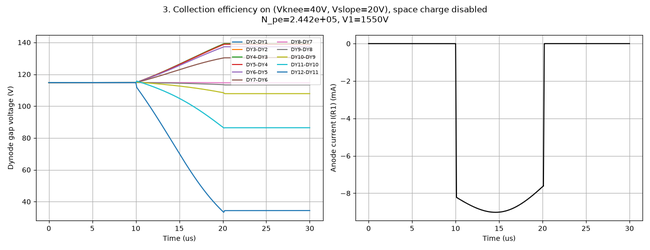
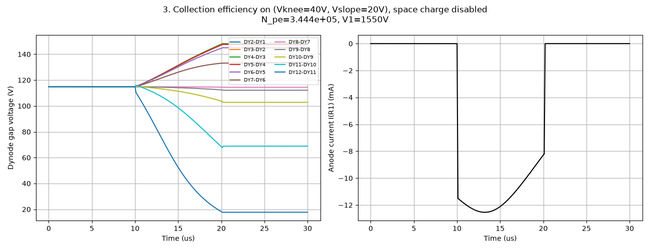
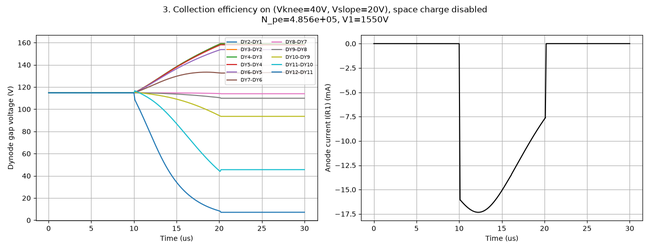
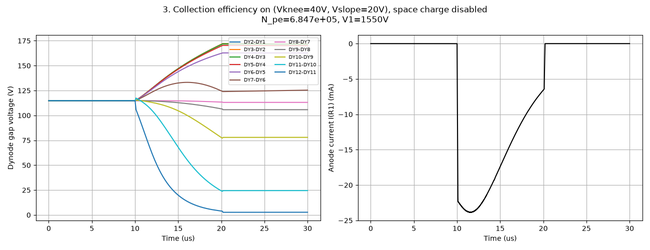
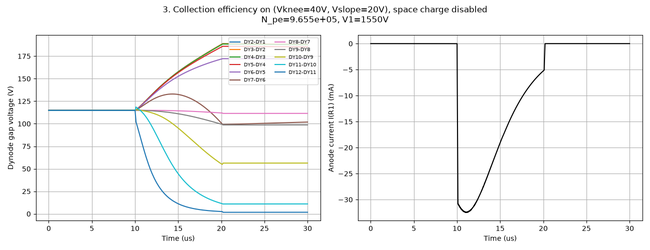
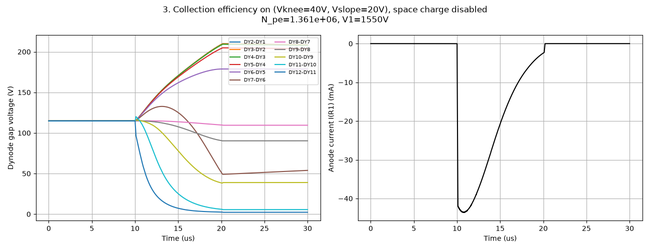
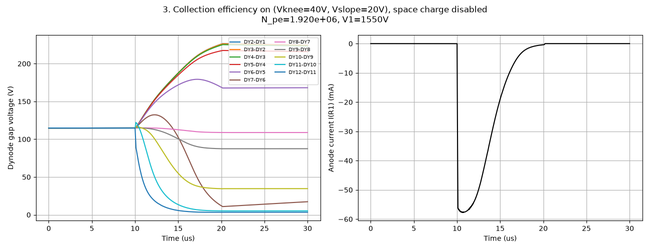
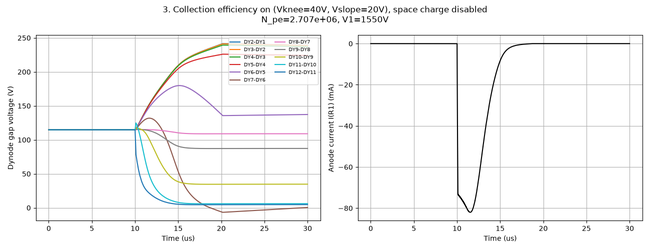
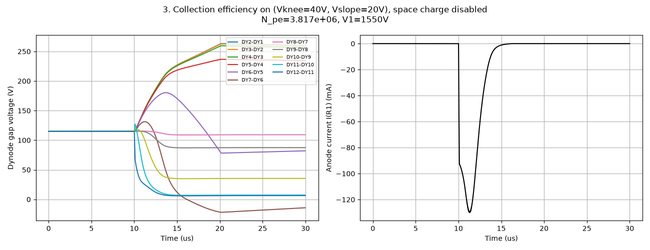
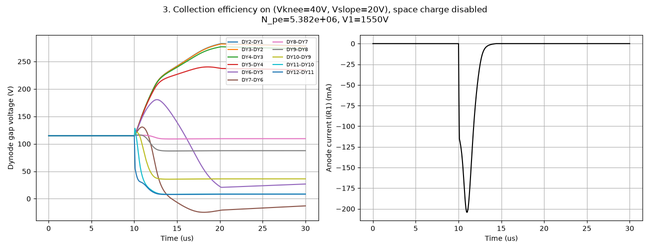
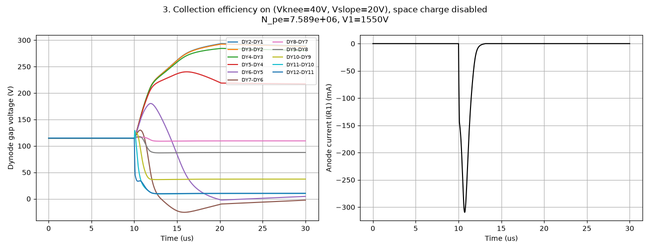
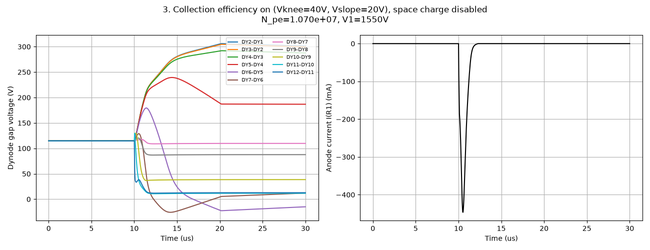
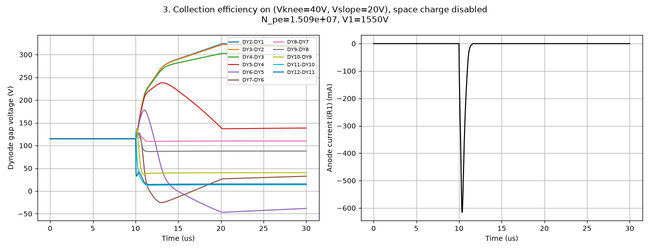
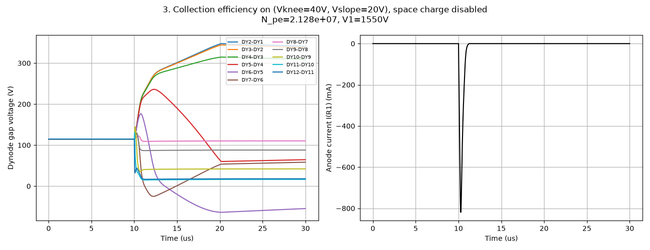
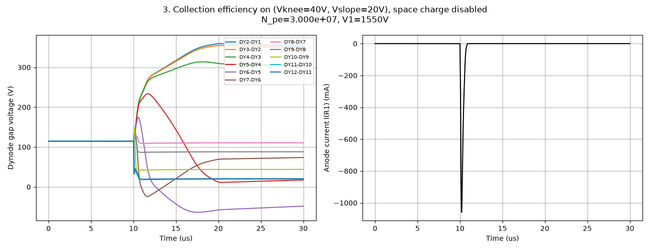
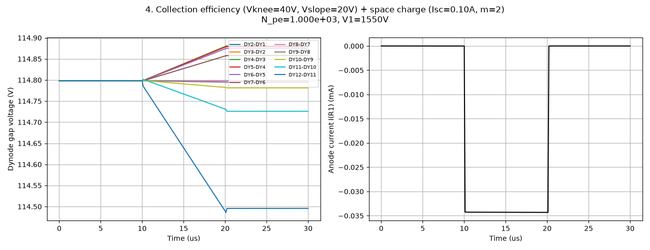
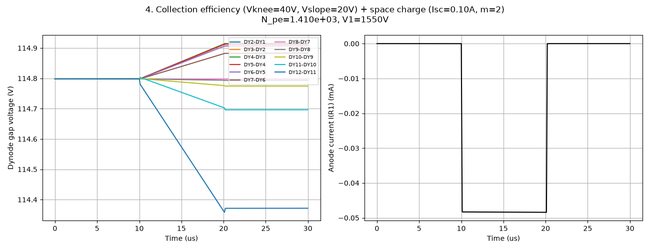
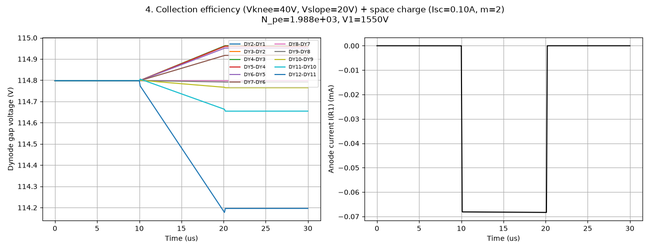
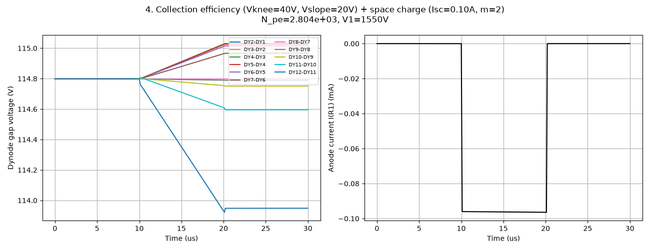
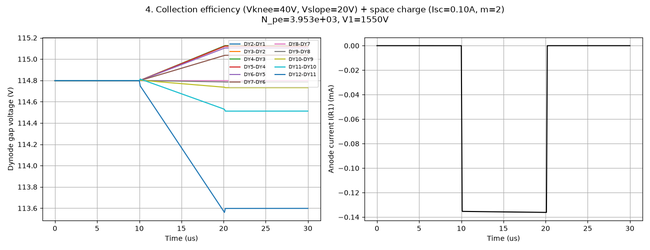
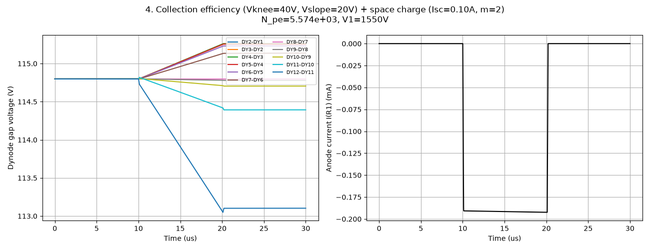
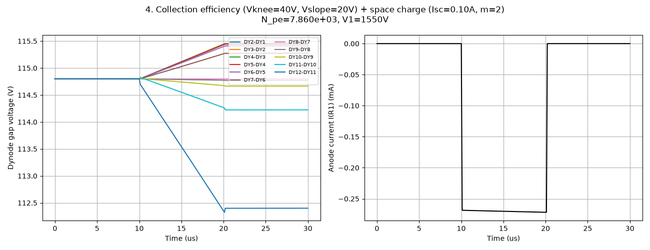
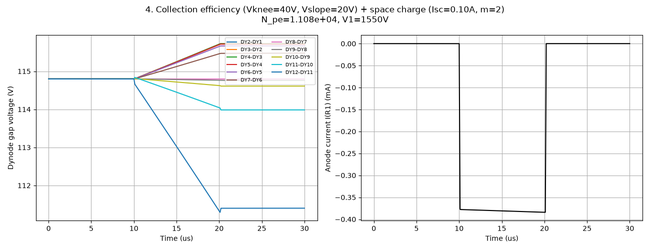
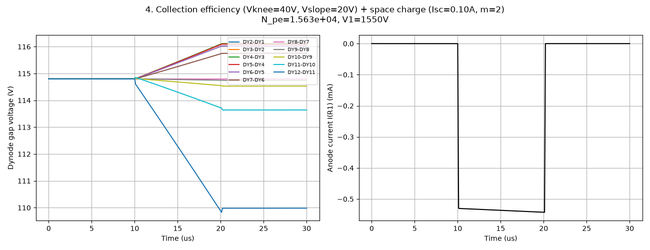
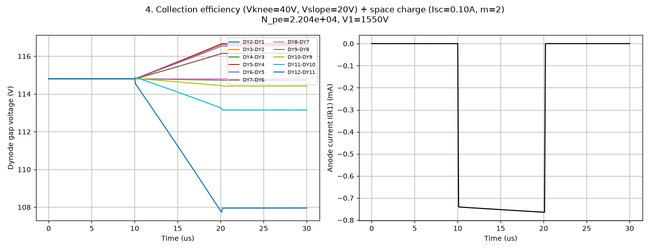
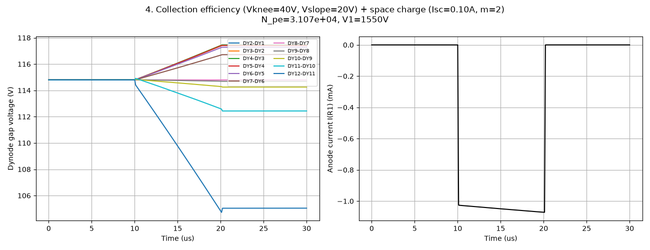
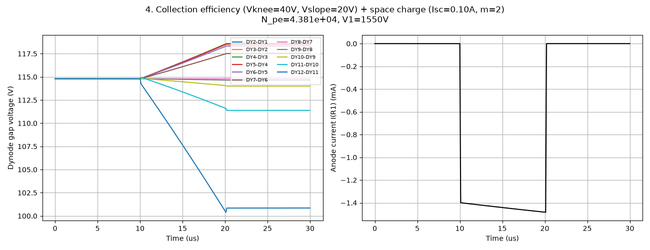
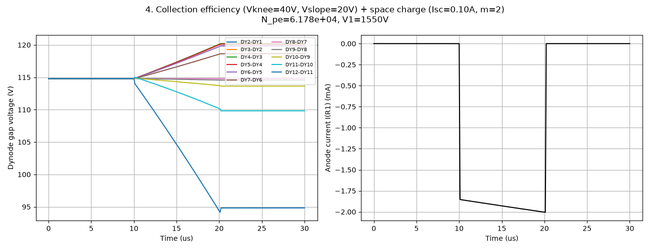
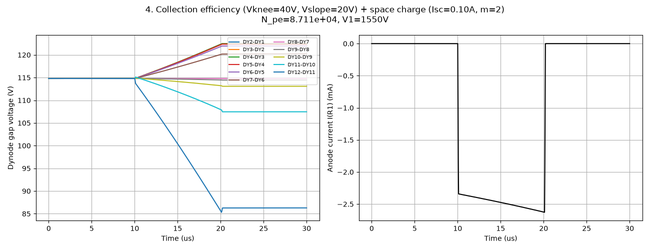
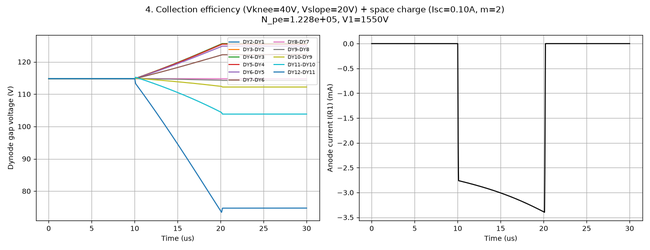
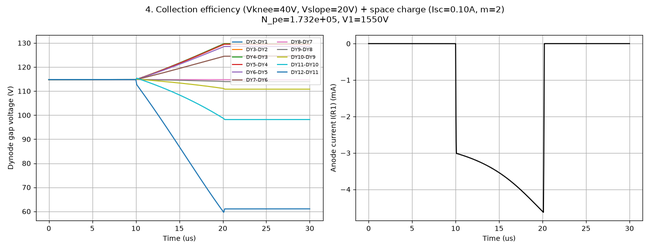
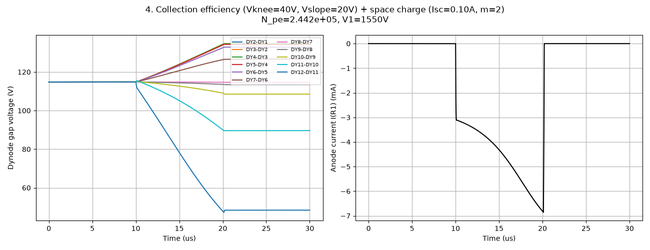
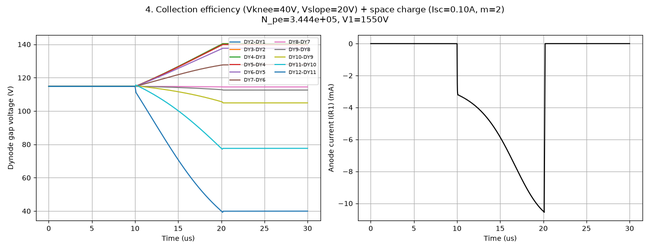
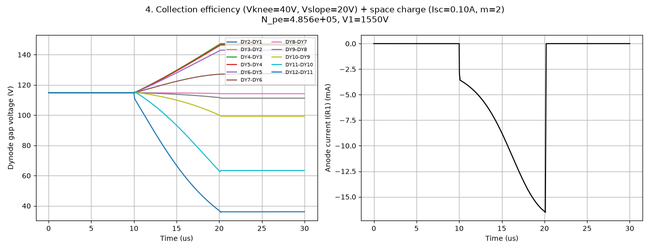
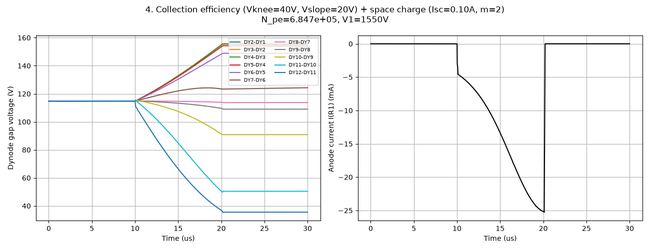
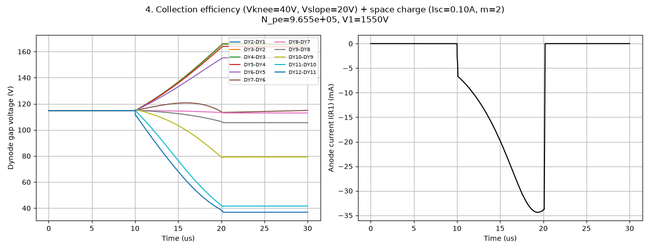
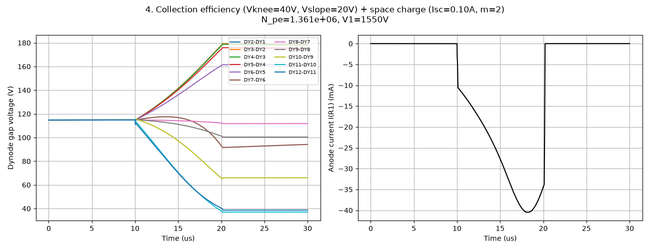
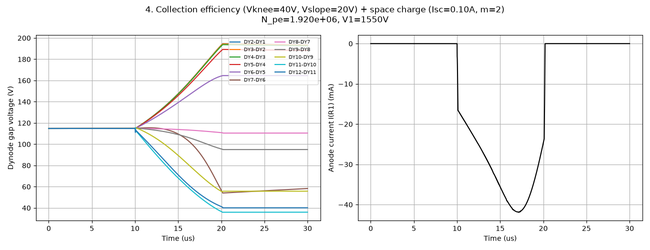
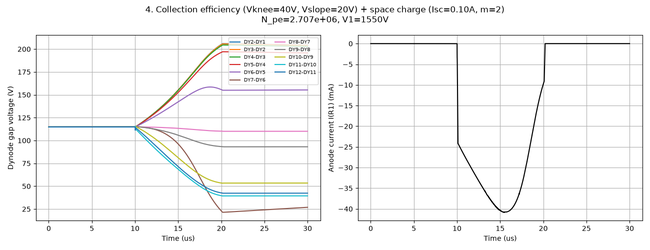
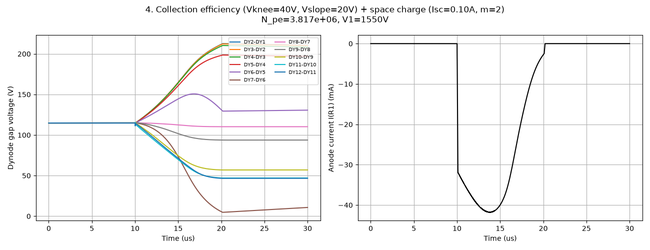
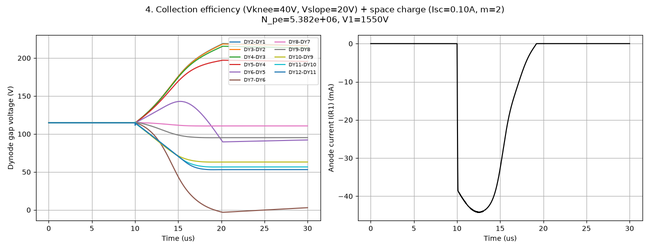
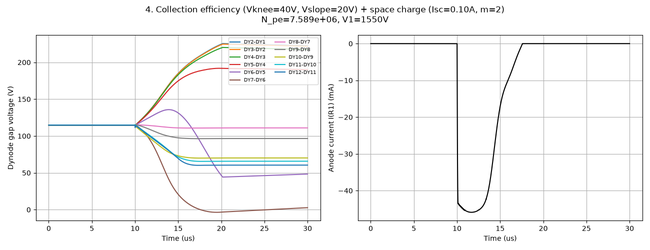
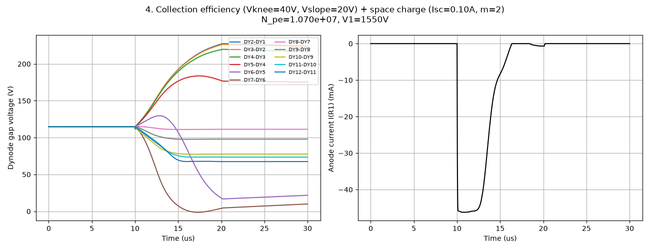
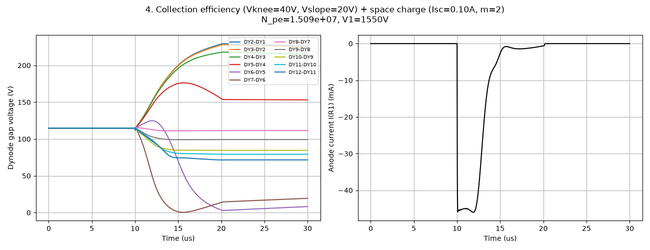
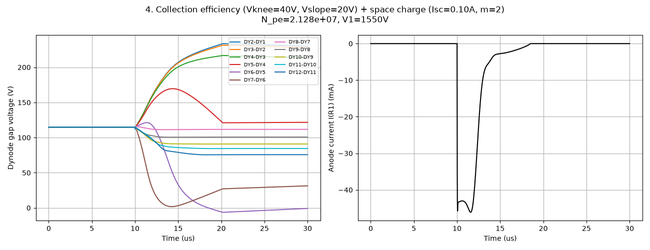
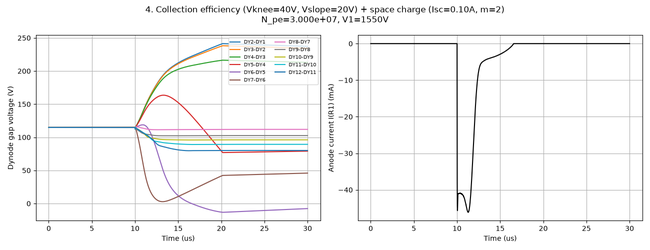

In [23]:
CONFIGS = [
    {
        "title": "1. Gain-only model (collection efficiency + space charge disabled)",
        "inc_params": {
            "VkneeAnode": -100, "VkneeOther": -100, "Vslope": 5,
            "Isc8": 1e9, "Isc9": 1e9, "Isc10": 1e9, "Isc11": 1e9, "Isc12": 1e9,
        },
    },
    {
        "title": "2. Collection efficiency on (Vknee=10V, Vslope=1V), space charge disabled",
        "inc_params": {
            "VkneeAnode": 10, "VkneeOther": 10, "Vslope": 1,
            "Isc8": 1e9, "Isc9": 1e9, "Isc10": 1e9, "Isc11": 1e9, "Isc12": 1e9,
        },
    },
    {
        "title": "3. Collection efficiency on (Vknee=40V, Vslope=20V), space charge disabled",
        "inc_params": {
            "VkneeAnode": 40, "VkneeOther": 40, "Vslope": 20,
            "Isc8": 1e9, "Isc9": 1e9, "Isc10": 1e9, "Isc11": 1e9, "Isc12": 1e9,
        },
    },
    {
        "title": "4. Collection efficiency (Vknee=40V, Vslope=20V) + space charge (Isc=0.10A, m=2)",
        "inc_params": {
            "VkneeAnode": 40, "VkneeOther": 40, "Vslope": 20,
            "Isc8": 0.1, "Isc9": 0.1, "Isc10": 0.1, "Isc11": 0.1, "Isc12": 0.1,
            "m": 2,
        },
    },
]

frames_2d = []
for cfg in CONFIGS:
    row = []
    for n_pe in DIAG_N_PE:
        try:
            t, dy, anode_current = run_diagnostic(n_pe, cfg["inc_params"], run_name="diag")
            fig = make_diagnostic_figure(t, dy, anode_current, n_pe, cfg["title"])
            row.append(fig_to_data_uri(fig))
        except (SimTimeoutError, RuntimeError) as exc:
            print(f"Skipping {cfg['title']!r} at N_pe={n_pe:.3e}: LTspice failed to converge ({exc})")
            row.append(placeholder_frame(f"LTspice failed to converge\nN_pe={n_pe:.3e}"))
    frames_2d.append(row)

from IPython.display import HTML, display

display(HTML(slider_gallery(
    frames_2d,
    row_labels=[cfg["title"] for cfg in CONFIGS],
    col_labels=[f"{n_pe:.2e}" for n_pe in DIAG_N_PE],
    row_title="Configuration",
    col_title="N_pe",
)))